## Data loading

##### The goal of this project is to analyze the financial performance of sample data and calculate Sales by  different countries, Profit of different countries, profit margin, total dicount, total revenue and visualize with the charts like bar plot, histogram, heat map.



In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data for pandas to read the file

df = pd.read_csv('/content/financial_data.csv')
display(df.head(2))
df.info()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",1/1/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",1/1/2014,1,January,2014


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

# Data Exploration

In [38]:
# Display the shape , describe stats mean, and checking nulls and unique values
display(df.shape)
display(df.describe())
display(df.nunique())
display(df.isnull().sum())

(700, 16)

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


,0
Segment,5
Country,5
Product,6
Discount Band,4
Units Sold,510
Manufacturing Price,6
Sale Price,7
Gross Sales,550
Discounts,515
Sales,559


,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


## Data wrangling



In [39]:
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

# Replacing and cleaning the columns (removing '$' with '', '-' with '0'.)
columns_to_clean = ['Sales', 'COGS', 'Profit', 'Manufacturing Price', 'Sale Price', 'Units Sold', 'Gross Sales', 'Discounts']

for col in columns_to_clean:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace(' -   ', '0', regex=False).str.replace('-', '0', regex=False).str.replace('(', '-', regex=False).str.replace(')', '', regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert 'Profit' column to integer type
df['Profit'] = df['Profit'].astype(int)

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        700 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    float64
 6   Sale Price           700 non-null    float64
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9   Sales                700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    int64  
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

None

## Data analysis



In [40]:
# Calculate the profit margin
Profit_margin = (df['Profit'] / df['Sales'])* 100
print(f"\n Profit margin: {Profit_margin}")


# Group by Country and calculate the mean Profit
profit_by_country = df.groupby('Country')['Profit'].mean().sort_values(ascending=False)

# Group by Country and calculate the mean Sales
sales_by_country = df.groupby('Country')['Sales'].mean().sort_values(ascending=False)

# Display the mean sales by country
print("Mean Sales by Country:")
display(sales_by_country)

# Calculate the total Discount
Total_dicounts = df['Discounts'].sum()
print(f"\n Total Dicsount : {Total_dicounts}")

# Calculate the Total Revenue
Total_revenue = df['Sales'].sum()
print(f"\n Total Revenue : {Total_revenue}")

# Calculate the Total Profit
Total_profit = df['Profit'].sum()
print(f"\n Total Profit : {Total_profit}")

# Calculate the COGS to sales ratio
df['COGS to Sales Ratio'] = df['COGS'] / df['Sales']
print(f"\n COGS to Sales Ratio : {df['COGS to Sales Ratio']}")


#  Calculate and display descriptive statistics
cleaned_numeric_cols = ['Sales', 'COGS', 'Profit', 'Manufacturing Price', 'Sale Price']
print(f"\nDescriptive Statistics:")
display(df[cleaned_numeric_cols].describe())

#  Calculate and display the correlation matrix
print(f"\nCorrelation Matrix:")
display(df[cleaned_numeric_cols].corr())

#  Group by 'Country' and calculate mean 'Profit'
print(f"\nMean Profit by Country:")
display(df.groupby('Country')['Profit'].mean())

#  Group by 'Product' and calculate mean 'Sales'
print(f"\nMean Sales by Product:")
display(df.groupby('Product')['Sales'].mean())




 Profit margin: 0      50.000000
1      50.000000
2      33.333333
3      33.333333
4      33.333333
         ...    
695     1.960784
696     1.960784
697    15.959015
698    15.946628
699    70.587150
Length: 700, dtype: float64
Mean Sales by Country:


,Sales
Country,
United States of America,178784.501214
Canada,177768.963429
France,173958.373500
Germany,167895.291571
Mexico,149638.229357



 Total Dicsount : 9205248.26

 Total Revenue : 118726350.27000001

 Total Profit : 16893534

 COGS to Sales Ratio : 0      0.500000
1      0.500000
2      0.666667
3      0.666667
4      0.666667
         ...   
695    0.980392
696    0.980392
697    0.840336
698    0.840336
699    0.294118
Name: COGS to Sales Ratio, Length: 700, dtype: float64

Descriptive Statistics:


,Sales,COGS,Profit,Manufacturing Price,Sale Price
count,7.000000e+02,700.000000,700.000000,700.000000,700.000000
mean,1.696091e+05,145475.211429,24133.620000,96.477143,118.428571
std,2.367263e+05,203865.506118,42760.665025,108.602612,136.775515
min,1.655080e+03,918.000000,-40617.000000,3.000000,7.000000
25%,1.592800e+04,7490.000000,2805.750000,5.000000,12.000000
50%,3.554020e+04,22506.250000,9241.500000,10.000000,20.000000
75%,2.610775e+05,245607.500000,22662.000000,250.000000,300.000000
max,1.159200e+06,950625.000000,262200.000000,260.000000,350.000000



Correlation Matrix:


,Sales,COGS,Profit,Manufacturing Price,Sale Price
Sales,1.000000,0.992244,0.805464,0.051549,0.805878
COGS,0.992244,1.000000,0.725547,0.046857,0.799335
Profit,0.805464,0.725547,1.000000,0.061986,0.650498
Manufacturing Price,0.051549,0.046857,0.061986,1.000000,0.070786
Sale Price,0.805878,0.799335,0.650498,0.070786,1.000000



Mean Profit by Country:


,Profit
Country,
Canada,25208.528571
France,27007.050000
Germany,26288.264286
Mexico,20767.785714
United States of America,21396.471429



Mean Sales by Product:


,Sales
Product,
Amarilla,188799.107021
Carretera,148551.697742
Montana,165492.493333
Paseo,163421.504703
VTT,188182.761651
Velo,167431.738257


# Data Visualization


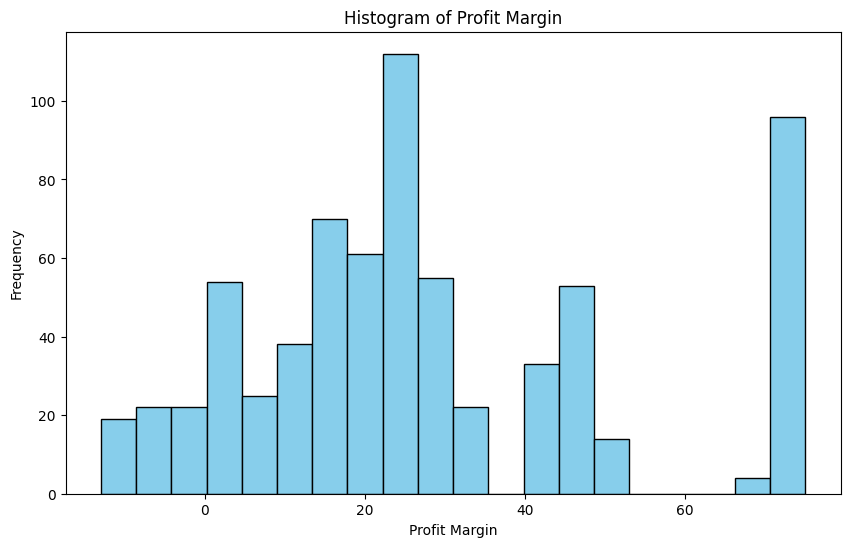

/tmp/ipython-input-41-3138136324.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_country.index, y=profit_by_country.values, palette='viridis')


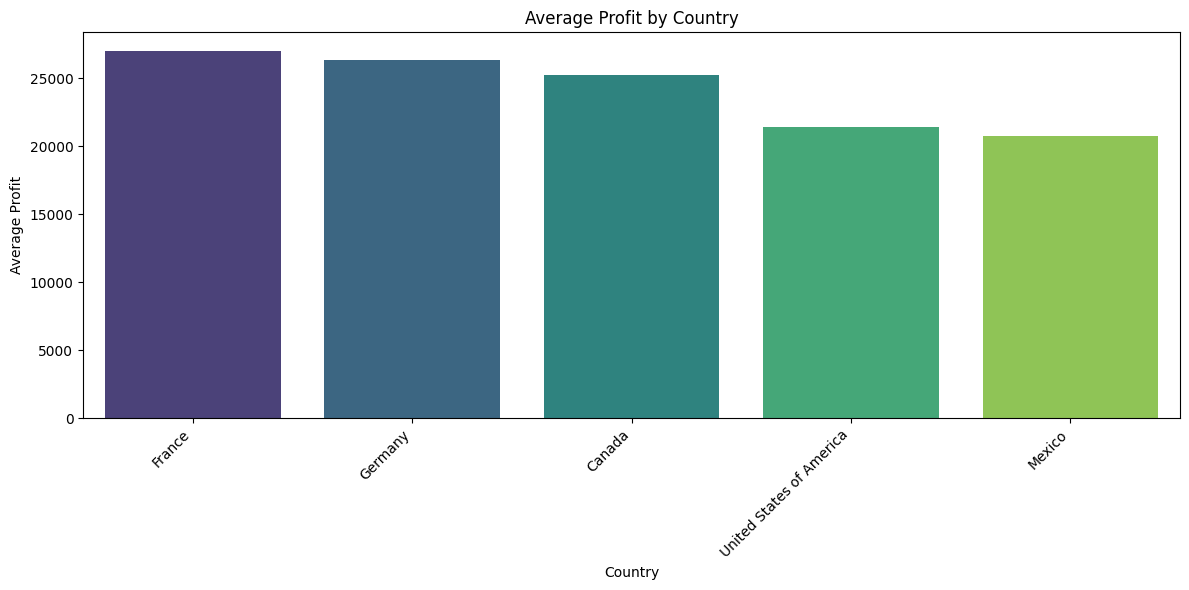

/tmp/ipython-input-41-3138136324.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_country.index, y=sales_by_country.values, palette='viridis')


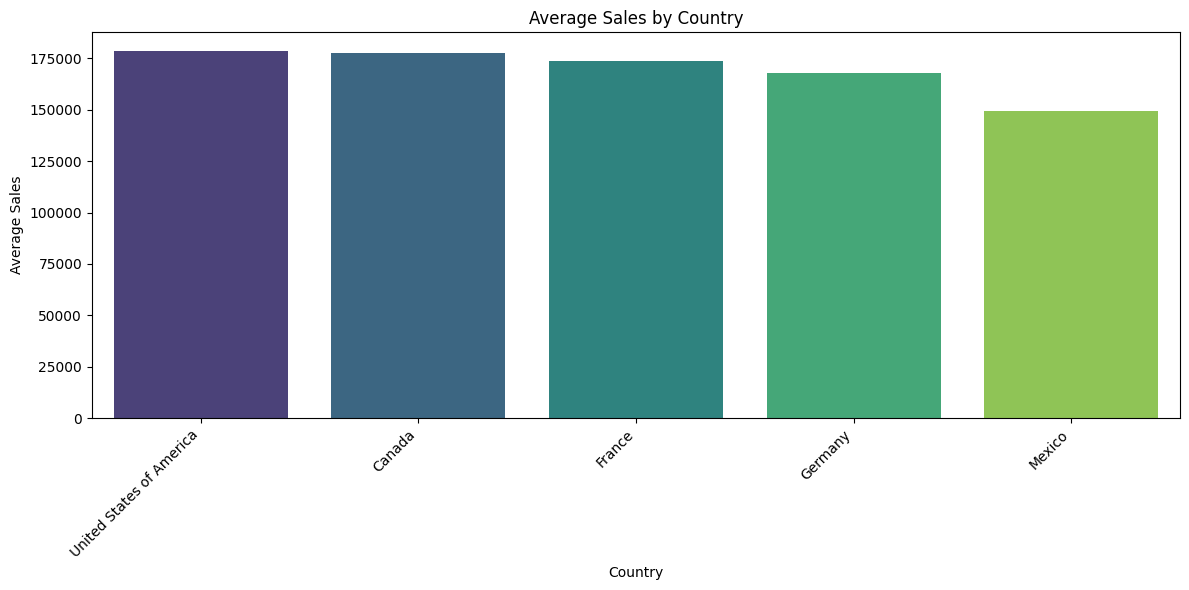

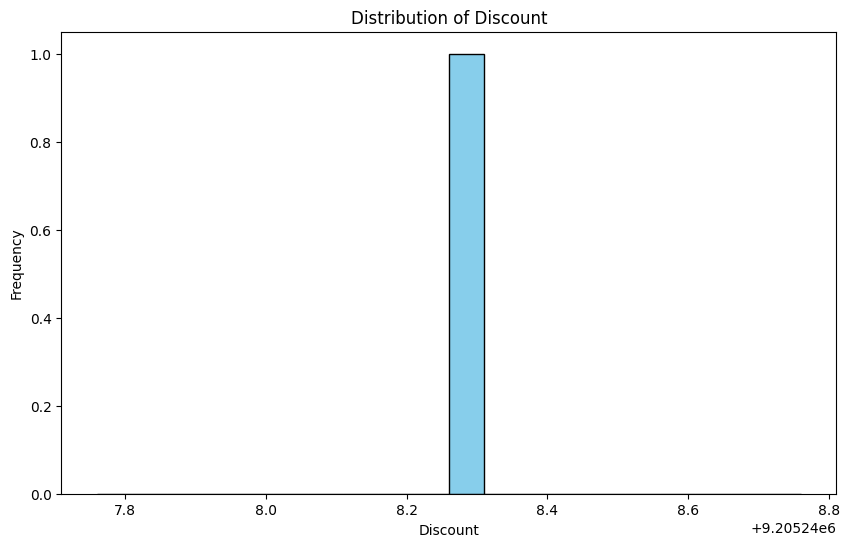

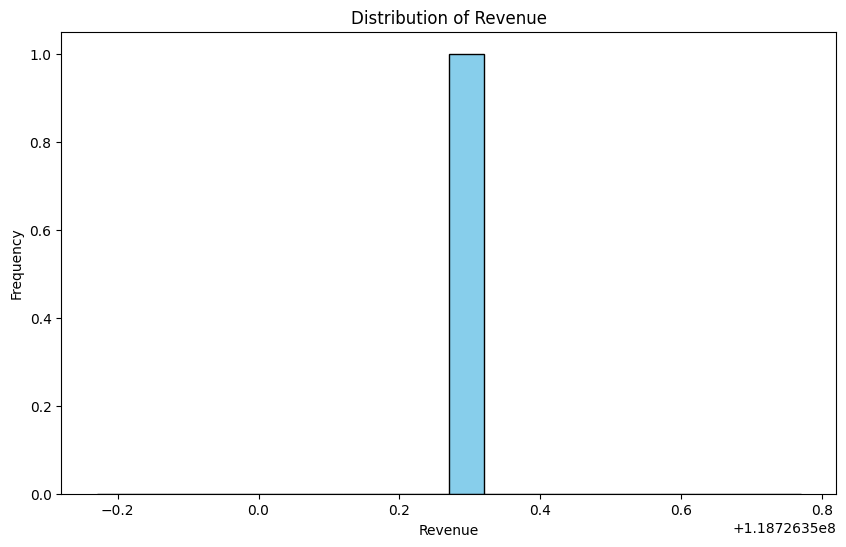

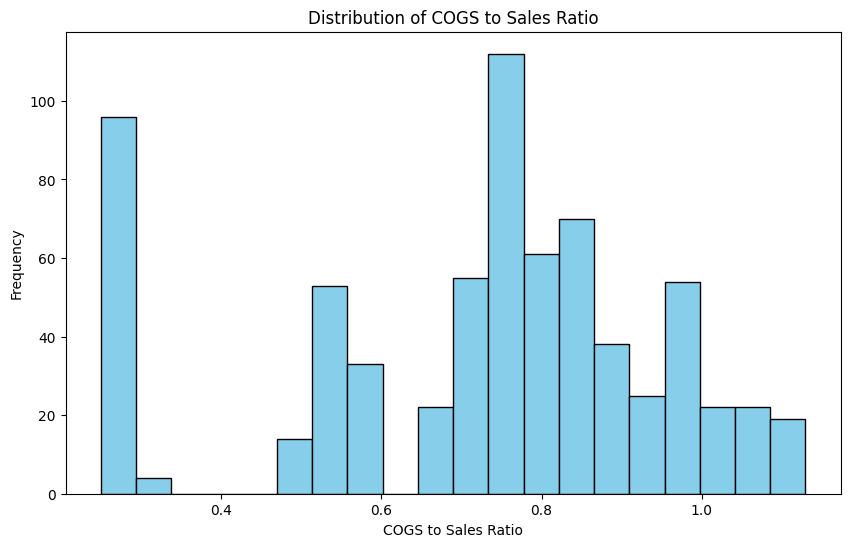

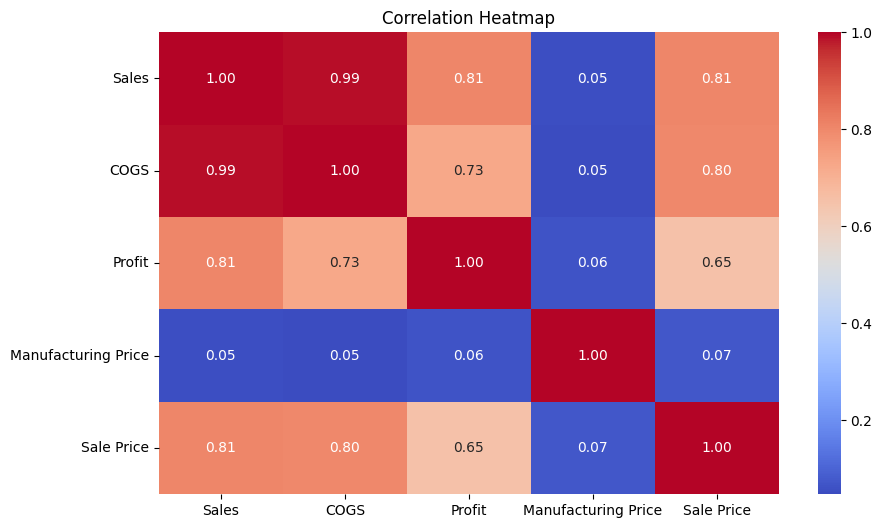

In [41]:
# Create Histogram for Profit margin
plt.figure(figsize=(10, 6))
plt.hist(Profit_margin, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.title('Histogram of Profit Margin')
plt.show()

# Create a bar plot for Average profit by country
plt.figure(figsize=(12, 6))
sns.barplot(x=profit_by_country.index, y=profit_by_country.values, palette='viridis')
plt.xlabel('Country')
plt.ylabel('Average Profit')
plt.title('Average Profit by Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# Create a bar plot of Average sales by country
plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_country.index, y=sales_by_country.values, palette='viridis')
plt.xlabel('Country')
plt.ylabel('Average Sales')
plt.title('Average Sales by Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create Histogram for Total Dicount
plt.figure(figsize=(10, 6))
plt.hist(Total_dicounts, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

# Create histogram for Total sales(revenue)
plt.figure(figsize=(10, 6))
plt.hist(Total_revenue, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()


#Create Histogram for COGS to sales ratio
plt.figure(figsize=(10, 6))
plt.hist(df['COGS to Sales Ratio'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of COGS to Sales Ratio')
plt.xlabel('COGS to Sales Ratio')
plt.ylabel('Frequency')
plt.show()

# create correlation with heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[cleaned_numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


## Summary:

### Data Analysis Key Findings

*   The dataset contains 700 rows and 16 columns with no missing values.
* The highest frequency of profit margin is between 20 to 40.
* The highest Distribution of revenue is (0.2 to 0.4)
*   After cleaning and converting to numeric types, the ` Sales `, ` COGS `, ` Profit `, ` Manufacturing Price `, and ` Sale Price ` columns showed significant variability.
*   There is a strong positive correlation between ` Sales ` and ` COGS ` (0.992), and a moderately strong positive correlation between ` Sales ` and ` Profit ` (0.805). `Sale Price` also exhibits a strong positive correlation with ` Sales ` (0.806) and ` COGS ` (0.799).

